In [131]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

import cartopy.crs as ccrs
import matplotlib.cm as cm

import cartopy.feature as cfeature


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [132]:
#functions



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


In [119]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(35, -35), lon = slice(100,300))

clim = sst.sel(time = slice('1991', '2020')).mean(['time'])


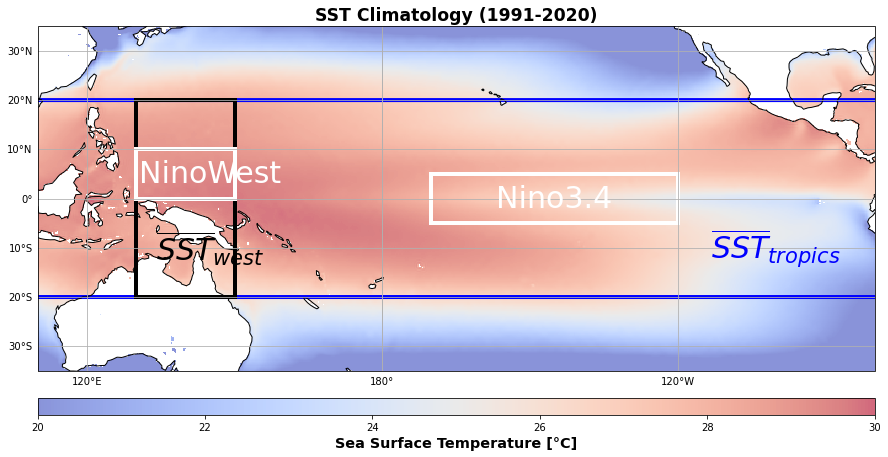

In [120]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



# Create a figure and axis with cartopy projection centered at 180° longitude
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Plot the SST data
sst = clim['sst']-273.15
c = ax.pcolormesh(sst['lon'], sst['lat'], sst, transform=ccrs.PlateCarree(),
                  cmap='coolwarm', shading='auto', vmin = 20, vmax = 30, alpha = 0.6)

# Add a colorbar
cbar = fig.colorbar(c, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Sea Surface Temperature [°C]')

# Set the title and axis labels
ax.set_title('SST Climatology (1991-2020)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.right_labels = False
gl.top_labels = False

# Define and plot the rectangles
rect1 = plt.Rectangle((2, -20), 358, 40, edgecolor='blue', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect2 = plt.Rectangle((130, -20), 20, 40, edgecolor='k', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect3 = plt.Rectangle((130, 0), 20, 10, edgecolor='w', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect4 = plt.Rectangle((190, -5), 50, 10, edgecolor='w', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())




#add text
ax.text(145, -10, r'$\overline{SST}_{west}$', color='k', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(260, -10, r'$\overline{SST}_{tropics}$', color='b', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(215, 0, r'Nino3.4', color='white', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(145, 5, r'NinoWest', color='white', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())


ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.add_patch(rect4)

ax.set_ylim(-35, 35)
ax.set_xlim(-70, 100)



plt.show()


In [122]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp).sel(lon = slice(100,300))
clim = w.sel(time = slice('1991', '2020')).mean(['time'])*(24*60*60)/100


In [123]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lon = slice(100,300), lat = slice(35,-35))
tp_clim = tp.sel(time = slice('1991', '2020')).mean(['time'])


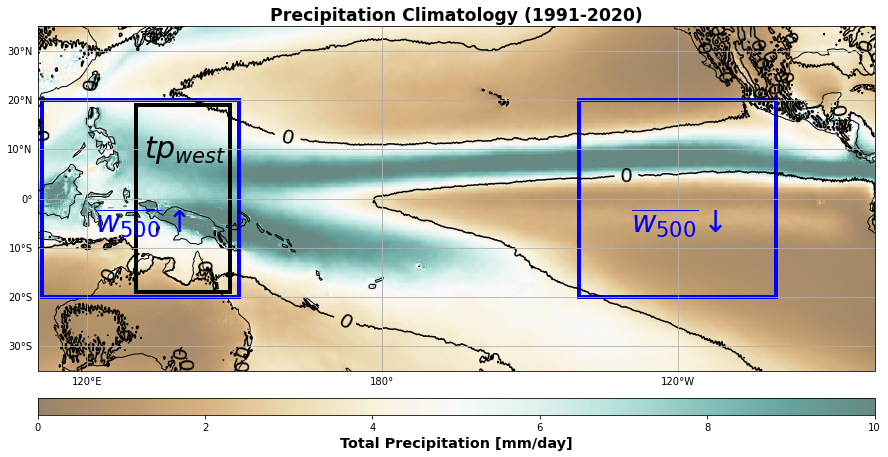

In [130]:
# Create a figure and axis with cartopy projection centered at 180° longitude
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Plot the w data
tp = tp_clim['tp']
c = ax.pcolormesh(tp['lon'], tp['lat'], tp, transform=ccrs.PlateCarree(),
                  cmap='BrBG', shading='auto', vmin = 0, vmax = 10, alpha = .6)

w = clim['w']
contour_levels = [-0]  # Define contour levels
cs = ax.contour(w['lon'], w['lat'], w, levels=contour_levels, transform=ccrs.PlateCarree(), colors = 'k')
ax.clabel(cs, inline=True, fontsize=20)


# Add a colorbar
cbar = fig.colorbar(c, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Total Precipitation [mm/day]')

# Set the title and axis labels
ax.set_title('Precipitation Climatology (1991-2020)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.right_labels = False
gl.top_labels = False

# Define and plot the rectangles
rect1 = plt.Rectangle((111, -20), 40, 40, edgecolor='b', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect2 = plt.Rectangle((220, -20), 40, 40, edgecolor='b', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect3 = plt.Rectangle((130, -19), 19, 38, edgecolor='k', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())


ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)

ax.text(131, -5, r'$\overline{w_{500}} \uparrow$', color='b', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(240, -5, r'$\overline{w_{500}} \downarrow$', color='b', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(140, 10, r'$tp_{west}$', color='k', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())


ax.set_ylim(-35, 35)
ax.set_xlim(-70, 100)

plt.show()


# Bony vs modified

In [133]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w = decode_time(fp).sel(lon = slice(100,300))
clim = w.sel(time = slice('1991', '2020')).mean(['time'])*(24*60*60)/100


In [123]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lon = slice(100,300), lat = slice(35,-35))
tp_clim = tp.sel(time = slice('1991', '2020')).mean(['time'])


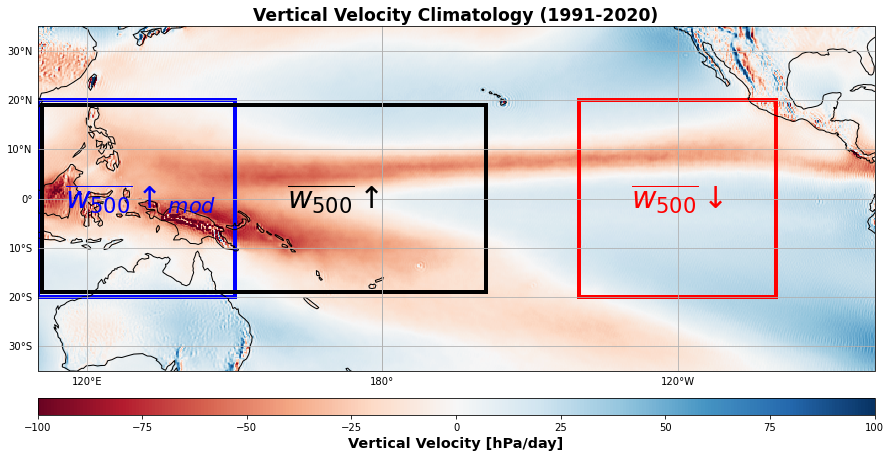

In [151]:
# Create a figure and axis with cartopy projection centered at 180° longitude
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Plot the w data
tp = tp_clim['tp']
c = ax.pcolormesh(tp['lon'], tp['lat'], tp, transform=ccrs.PlateCarree(),
                  cmap='BrBG', shading='auto', vmin = 0, vmax = 10, alpha = .6)

w = clim['w']
c = ax.pcolormesh(w['lon'], w['lat'],w, transform=ccrs.PlateCarree(),
                  cmap='RdBu', shading='auto', vmin = -100, vmax = 100, alpha = .99)

"""
contour_levels = [-0]  # Define contour levels
cs = ax.contour(w['lon'], w['lat'], w, levels=contour_levels, transform=ccrs.PlateCarree(), colors = 'k')
ax.clabel(cs, inline=True, fontsize=20)

"""
# Add a colorbar
cbar = fig.colorbar(c, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Vertical Velocity [hPa/day]')

# Set the title and axis labels
ax.set_title('Vertical Velocity Climatology (1991-2020)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.right_labels = False
gl.top_labels = False

# Define and plot the rectangles
rect1 = plt.Rectangle((110, -20), 40, 40, edgecolor='b', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect2 = plt.Rectangle((220, -20), 40, 40, edgecolor='r', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())
rect3 = plt.Rectangle((111, -19), 90, 38, edgecolor='k', facecolor='none', linewidth=4, transform=ccrs.PlateCarree())


ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)

ax.text(131, 0, r'$\overline{w_{500}} \uparrow _{mod}$', color='b', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(240, 0, r'$\overline{w_{500}} \downarrow$', color='r', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())
ax.text(170, 0, r'$\overline{w_{500}} \uparrow$', color='k', fontsize=30, ha='center', va='center', transform=ccrs.PlateCarree())


ax.set_ylim(-35, 35)
ax.set_xlim(-70, 100)

plt.show()
